In [22]:
import torch
import torch.nn as nn
import math
import os
from dataclasses import dataclass, field
from typing import Optional, List, Dict, Any
from torch.utils.data import Dataset, DataLoader

import json
import pandas as pd
import numpy as np
from transformers import Trainer, TrainingArguments, BertTokenizer
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import EarlyStoppingCallback

# HuggingFace Libraries
from transformers import (
    PreTrainedModel, PretrainedConfig, BertTokenizer, 
    Trainer, TrainingArguments, DataCollatorForLanguageModeling,
    DataCollatorWithPadding, EvalPrediction
)
from transformers.modeling_outputs import SequenceClassifierOutput, MaskedLMOutput
from datasets import load_dataset

# Sklearn for metrics (No 'evaluate' module needed)
from sklearn.metrics import accuracy_score, f1_score, matthews_corrcoef
from scipy.stats import pearsonr, spearmanr

In [39]:


# -----------------------------------------------------------------------------
# SBert (Standard BERT)
# -----------------------------------------------------------------------------

class SBertConfig(PretrainedConfig):
    model_type = "sbert"
    def __init__(self, vocab_size=30522, hidden_size=768, num_hidden_layers=12, 
                 num_attention_heads=12, intermediate_size=3072, hidden_act="gelu", 
                 hidden_dropout_prob=0.1, attention_probs_dropout_prob=0.1, 
                 max_position_embeddings=512, type_vocab_size=2, initializer_range=0.02, 
                 layer_norm_eps=1e-12, pad_token_id=0, position_embedding_type="absolute", 
                 use_cache=True, classifier_dropout=None, num_labels=2, **kwargs):
        super().__init__(pad_token_id=pad_token_id, **kwargs)
        self.vocab_size = vocab_size
        self.hidden_size = hidden_size
        self.num_hidden_layers = num_hidden_layers
        self.num_attention_heads = num_attention_heads
        self.hidden_act = hidden_act
        self.intermediate_size = intermediate_size
        self.hidden_dropout_prob = hidden_dropout_prob
        self.attention_probs_dropout_prob = attention_probs_dropout_prob
        self.max_position_embeddings = max_position_embeddings
        self.type_vocab_size = type_vocab_size
        self.initializer_range = initializer_range
        self.layer_norm_eps = layer_norm_eps
        self.position_embedding_type = position_embedding_type
        self.use_cache = use_cache
        self.classifier_dropout = classifier_dropout
        self.num_labels = num_labels

class SBertSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        if config.hidden_size % config.num_attention_heads != 0:
            raise ValueError("Hidden size must be divisible by number of attention heads")
        self.num_attention_heads = config.num_attention_heads
        self.attention_head_size = config.hidden_size // config.num_attention_heads
        self.all_head_size = self.num_attention_heads * self.attention_head_size
        self.query = nn.Linear(config.hidden_size, self.all_head_size)
        self.key = nn.Linear(config.hidden_size, self.all_head_size)
        self.value = nn.Linear(config.hidden_size, self.all_head_size)
        self.dropout = nn.Dropout(config.attention_probs_dropout_prob)

    def transpose_for_scores(self, x):
        new_x_shape = x.size()[:-1] + (self.num_attention_heads, self.attention_head_size)
        x = x.view(*new_x_shape)
        return x.permute(0, 2, 1, 3)

    def forward(self, hidden_states, attention_mask=None):
        query_layer = self.transpose_for_scores(self.query(hidden_states))
        key_layer = self.transpose_for_scores(self.key(hidden_states))
        value_layer = self.transpose_for_scores(self.value(hidden_states))
        attention_scores = torch.matmul(query_layer, key_layer.transpose(-1, -2))
        attention_scores = attention_scores / math.sqrt(self.attention_head_size)
        if attention_mask is not None:
            attention_scores = attention_scores + attention_mask
        attention_probs = nn.Softmax(dim=-1)(attention_scores)
        attention_probs = self.dropout(attention_probs)
        context_layer = torch.matmul(attention_probs, value_layer)
        context_layer = context_layer.permute(0, 2, 1, 3).contiguous()
        new_context_layer_shape = context_layer.size()[:-2] + (self.all_head_size,)
        return context_layer.view(*new_context_layer_shape)

class SBertLayer(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.attention = SBertSelfAttention(config)
        self.intermediate = nn.Linear(config.hidden_size, config.intermediate_size)
        self.output = nn.Linear(config.intermediate_size, config.hidden_size)
        self.LayerNorm1 = nn.LayerNorm(config.hidden_size, eps=config.layer_norm_eps)
        self.LayerNorm2 = nn.LayerNorm(config.hidden_size, eps=config.layer_norm_eps)
        self.dropout = nn.Dropout(config.hidden_dropout_prob)
        self.activation = nn.GELU()

    def forward(self, hidden_states, attention_mask=None):
        attention_output = self.attention(hidden_states, attention_mask)
        hidden_states = self.LayerNorm1(attention_output + hidden_states)
        intermediate_output = self.activation(self.intermediate(hidden_states))
        layer_output = self.dropout(self.output(intermediate_output))
        hidden_states = self.LayerNorm2(layer_output + hidden_states)
        return hidden_states

class SBertModel(PreTrainedModel):
    config_class = SBertConfig
    def __init__(self, config):
        super().__init__(config)
        self.config = config
        self.word_embeddings = nn.Embedding(config.vocab_size, config.hidden_size, padding_idx=config.pad_token_id)
        self.position_embeddings = nn.Embedding(config.max_position_embeddings, config.hidden_size)
        self.token_type_embeddings = nn.Embedding(config.type_vocab_size, config.hidden_size)
        self.LayerNorm = nn.LayerNorm(config.hidden_size, eps=config.layer_norm_eps)
        self.dropout = nn.Dropout(config.hidden_dropout_prob)
        self.layers = nn.ModuleList([SBertLayer(config) for _ in range(config.num_hidden_layers)])
        self.pooler = nn.Linear(config.hidden_size, config.hidden_size)
        self.tanh = nn.Tanh()

    def forward(self, input_ids, attention_mask=None, token_type_ids=None, position_ids=None):
        if attention_mask is None:
            attention_mask = torch.ones_like(input_ids)
        extended_attention_mask = attention_mask[:, None, None, :]
        extended_attention_mask = (1.0 - extended_attention_mask) * -10000.0
        seq_length = input_ids.size(1)
        if position_ids is None:
            position_ids = torch.arange(seq_length, dtype=torch.long, device=input_ids.device).unsqueeze(0)
        if token_type_ids is None:
            token_type_ids = torch.zeros(input_ids.size(), dtype=torch.long, device=input_ids.device)
        
        embeddings = self.word_embeddings(input_ids) + self.position_embeddings(position_ids) + self.token_type_embeddings(token_type_ids)
        embeddings = self.dropout(self.LayerNorm(embeddings))
        hidden_states = embeddings
        for layer in self.layers:
            hidden_states = layer(hidden_states, extended_attention_mask)
        pooled_output = self.tanh(self.pooler(hidden_states[:, 0]))
        return hidden_states, pooled_output

class SBertForMaskedLM(PreTrainedModel):
    config_class = SBertConfig
    def __init__(self, config):
        super().__init__(config)
        self.bert = SBertModel(config)
        self.cls = nn.Linear(config.hidden_size, config.vocab_size)
    
    def forward(self, input_ids, attention_mask=None, labels=None, **kwargs):
        hidden_states, _ = self.bert(input_ids, attention_mask=attention_mask)
        prediction_scores = self.cls(hidden_states)
        loss = None
        if labels is not None:
            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(prediction_scores.view(-1, self.config.vocab_size), labels.view(-1))
        return MaskedLMOutput(loss=loss, logits=prediction_scores)

class SBertForSequenceClassification(PreTrainedModel):
    config_class = SBertConfig
    def __init__(self, config):
        super().__init__(config)
        self.num_labels = config.num_labels
        self.bert = SBertModel(config)
        self.dropout = nn.Dropout(config.hidden_dropout_prob)
        self.classifier = nn.Linear(config.hidden_size, config.num_labels)

    def forward(self, input_ids, attention_mask=None, labels=None, **kwargs):
        _, pooled_output = self.bert(input_ids, attention_mask=attention_mask)
        pooled_output = self.dropout(pooled_output)
        logits = self.classifier(pooled_output)
        loss = None
        if labels is not None:
            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(logits.view(-1, self.num_labels), labels.view(-1))
        return SequenceClassifierOutput(loss=loss, logits=logits)

# -----------------------------------------------------------------------------
# CBert (Complex BERT)
# -----------------------------------------------------------------------------

class CBertConfig(PretrainedConfig):
    model_type = "cbert"
    def __init__(self, vocab_size=30522, hidden_size=768, num_hidden_layers=12, 
                 num_attention_heads=12, intermediate_size=3072, hidden_act="gelu", 
                 hidden_dropout_prob=0.1, attention_probs_dropout_prob=0.1, 
                 max_position_embeddings=512, type_vocab_size=2, num_labels=2, **kwargs):
        super().__init__(**kwargs)
        self.vocab_size = vocab_size
        self.hidden_size = hidden_size
        self.num_hidden_layers = num_hidden_layers
        self.num_attention_heads = num_attention_heads
        self.intermediate_size = intermediate_size
        self.hidden_act = hidden_act
        self.hidden_dropout_prob = hidden_dropout_prob
        self.attention_probs_dropout_prob = attention_probs_dropout_prob
        self.max_position_embeddings = max_position_embeddings
        self.type_vocab_size = type_vocab_size
        self.layer_norm_eps = 1e-12
        self.num_labels = num_labels

class ComplexLinear(nn.Module):
    def __init__(self, in_features, out_features, bias=True):
        super().__init__()
        self.in_features = in_features // 2
        self.out_features = out_features // 2
        self.weight_real = nn.Parameter(torch.Tensor(self.out_features, self.in_features))
        self.weight_imag = nn.Parameter(torch.Tensor(self.out_features, self.in_features))
        if bias:
            self.bias_real = nn.Parameter(torch.Tensor(self.out_features))
            self.bias_imag = nn.Parameter(torch.Tensor(self.out_features))
        else:
            self.register_parameter('bias_real', None)
            self.register_parameter('bias_imag', None)
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.kaiming_uniform_(self.weight_real, a=math.sqrt(5))
        nn.init.kaiming_uniform_(self.weight_imag, a=math.sqrt(5))
        if self.bias_real is not None:
            nn.init.zeros_(self.bias_real)
            nn.init.zeros_(self.bias_imag)

    def forward(self, x):
        x_real = x[:, :, :self.in_features]
        x_imag = x[:, :, self.in_features:]
        out_real = torch.matmul(x_real, self.weight_real.t()) - torch.matmul(x_imag, self.weight_imag.t())
        out_imag = torch.matmul(x_real, self.weight_imag.t()) + torch.matmul(x_imag, self.weight_real.t())
        if self.bias_real is not None:
            out_real += self.bias_real
            out_imag += self.bias_imag
        return torch.cat([out_real, out_imag], dim=-1)

class CBertSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.num_attention_heads = config.num_attention_heads
        self.attention_head_size = config.hidden_size // config.num_attention_heads
        self.all_head_size = self.num_attention_heads * self.attention_head_size
        self.query = ComplexLinear(config.hidden_size, self.all_head_size)
        self.key = ComplexLinear(config.hidden_size, self.all_head_size)
        self.value = ComplexLinear(config.hidden_size, self.all_head_size)
        self.dropout = nn.Dropout(config.attention_probs_dropout_prob)

    def transpose_for_scores(self, x):
        new_x_shape = x.size()[:-1] + (self.num_attention_heads, self.attention_head_size)
        x = x.view(*new_x_shape)
        return x.permute(0, 2, 1, 3)

    def forward(self, hidden_states, attention_mask=None):
        query_layer = self.transpose_for_scores(self.query(hidden_states))
        key_layer = self.transpose_for_scores(self.key(hidden_states))
        value_layer = self.transpose_for_scores(self.value(hidden_states))
        
        query_real = query_layer[:, :, :, :self.attention_head_size//2]
        key_real = key_layer[:, :, :, :self.attention_head_size//2]
        
        attention_scores = torch.matmul(query_real, key_real.transpose(-1, -2))
        attention_scores = attention_scores / math.sqrt(self.attention_head_size // 2)
        if attention_mask is not None:
            attention_scores = attention_scores + attention_mask
        
        attention_probs = nn.Softmax(dim=-1)(attention_scores)
        attention_probs = self.dropout(attention_probs)
        context_layer = torch.matmul(attention_probs, value_layer)
        context_layer = context_layer.permute(0, 2, 1, 3).contiguous()
        new_context_layer_shape = context_layer.size()[:-2] + (self.all_head_size,)
        return context_layer.view(*new_context_layer_shape)

class CBertLayer(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.attention = CBertSelfAttention(config)
        self.intermediate = ComplexLinear(config.hidden_size, config.intermediate_size)
        self.output = ComplexLinear(config.intermediate_size, config.hidden_size)
        self.LayerNorm1 = nn.LayerNorm(config.hidden_size, eps=config.layer_norm_eps)
        self.LayerNorm2 = nn.LayerNorm(config.hidden_size, eps=config.layer_norm_eps)
        self.dropout = nn.Dropout(config.hidden_dropout_prob)
        self.activation = nn.GELU()

    def forward(self, hidden_states, attention_mask=None):
        attention_output = self.attention(hidden_states, attention_mask)
        hidden_states = self.LayerNorm1(attention_output + hidden_states)
        intermediate_output = self.activation(self.intermediate(hidden_states))
        layer_output = self.dropout(self.output(intermediate_output))
        hidden_states = self.LayerNorm2(layer_output + hidden_states)
        return hidden_states

class CBertModel(PreTrainedModel):
    config_class = CBertConfig
    def __init__(self, config):
        super().__init__(config)
        self.config = config
        self.word_embeddings = nn.Embedding(config.vocab_size, config.hidden_size, padding_idx=0)
        self.position_embeddings = nn.Embedding(config.max_position_embeddings, config.hidden_size)
        self.token_type_embeddings = nn.Embedding(config.type_vocab_size, config.hidden_size)
        self.LayerNorm = nn.LayerNorm(config.hidden_size, eps=config.layer_norm_eps)
        self.dropout = nn.Dropout(config.hidden_dropout_prob)
        self.layers = nn.ModuleList([CBertLayer(config) for _ in range(config.num_hidden_layers)])
        self.pooler = nn.Linear(config.hidden_size, config.hidden_size)
        self.tanh = nn.Tanh()

    def forward(self, input_ids, attention_mask=None, token_type_ids=None, position_ids=None):
        if attention_mask is None:
            attention_mask = torch.ones_like(input_ids)
        extended_attention_mask = attention_mask[:, None, None, :]
        extended_attention_mask = (1.0 - extended_attention_mask) * -10000.0
        
        seq_length = input_ids.size(1)
        if position_ids is None:
            position_ids = torch.arange(seq_length, dtype=torch.long, device=input_ids.device).unsqueeze(0)
        if token_type_ids is None:
            token_type_ids = torch.zeros(input_ids.size(), dtype=torch.long, device=input_ids.device)

        embeddings = self.word_embeddings(input_ids) + self.position_embeddings(position_ids) + self.token_type_embeddings(token_type_ids)
        embeddings = self.dropout(self.LayerNorm(embeddings))
        hidden_states = embeddings
        for layer in self.layers:
            hidden_states = layer(hidden_states, extended_attention_mask)
        pooled_output = self.tanh(self.pooler(hidden_states[:, 0]))
        return hidden_states, pooled_output

class CBertForMaskedLM(PreTrainedModel):
    config_class = CBertConfig
    def __init__(self, config):
        super().__init__(config)
        self.cbert = CBertModel(config)
        self.cls = nn.Linear(config.hidden_size, config.vocab_size)

    def forward(self, input_ids, attention_mask=None, labels=None, **kwargs):
        hidden_states, _ = self.cbert(input_ids, attention_mask=attention_mask)
        prediction_scores = self.cls(hidden_states)
        loss = None
        if labels is not None:
            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(prediction_scores.view(-1, self.config.vocab_size), labels.view(-1))
        return MaskedLMOutput(loss=loss, logits=prediction_scores)

class CBertForSequenceClassification(PreTrainedModel):
    config_class = CBertConfig
    def __init__(self, config):
        super().__init__(config)
        self.num_labels = config.num_labels
        self.cbert = CBertModel(config)
        self.dropout = nn.Dropout(config.hidden_dropout_prob)
        self.classifier = nn.Linear(config.hidden_size, config.num_labels)

    def forward(self, input_ids, attention_mask=None, labels=None, **kwargs):
        _, pooled_output = self.cbert(input_ids, attention_mask=attention_mask)
        pooled_output = self.dropout(pooled_output)
        logits = self.classifier(pooled_output)
        loss = None
        if labels is not None:
            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(logits.view(-1, self.num_labels), labels.view(-1))
        return SequenceClassifierOutput(loss=loss, logits=logits)

# -----------------------------------------------------------------------------
# QBert (Quaternion BERT)
# -----------------------------------------------------------------------------

class QBertConfig(PretrainedConfig):
    model_type = "qbert"
    def __init__(self, vocab_size=30522, hidden_size=768, num_hidden_layers=12, 
                 num_attention_heads=12, intermediate_size=3072, hidden_act="gelu", 
                 hidden_dropout_prob=0.1, attention_probs_dropout_prob=0.1, 
                 max_position_embeddings=512, type_vocab_size=2, num_labels=2, 
                 weighted_qk_concat=True, quaternion_mode="all", **kwargs):
        super().__init__(**kwargs)
        self.vocab_size = vocab_size
        self.hidden_size = hidden_size
        self.num_hidden_layers = num_hidden_layers
        self.num_attention_heads = num_attention_heads
        self.intermediate_size = intermediate_size
        self.hidden_act = hidden_act
        self.hidden_dropout_prob = hidden_dropout_prob
        self.attention_probs_dropout_prob = attention_probs_dropout_prob
        self.max_position_embeddings = max_position_embeddings
        self.type_vocab_size = type_vocab_size
        self.layer_norm_eps = 1e-12
        self.num_labels = num_labels
        self.weighted_qk_concat = weighted_qk_concat
        self.quaternion_mode = quaternion_mode

class QuaternionLinear(nn.Module):
    def __init__(self, in_features, out_features, bias=True):
        super().__init__()
        self.in_features = in_features // 4
        self.out_features = out_features // 4
        self.weight_r = nn.Parameter(torch.Tensor(self.out_features, self.in_features))
        self.weight_i = nn.Parameter(torch.Tensor(self.out_features, self.in_features))
        self.weight_j = nn.Parameter(torch.Tensor(self.out_features, self.in_features))
        self.weight_k = nn.Parameter(torch.Tensor(self.out_features, self.in_features))
        if bias:
            self.bias_r = nn.Parameter(torch.Tensor(self.out_features))
            self.bias_i = nn.Parameter(torch.Tensor(self.out_features))
            self.bias_j = nn.Parameter(torch.Tensor(self.out_features))
            self.bias_k = nn.Parameter(torch.Tensor(self.out_features))
        else:
            self.register_parameter('bias_r', None)
            self.register_parameter('bias_i', None)
            self.register_parameter('bias_j', None)
            self.register_parameter('bias_k', None)
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.kaiming_uniform_(self.weight_r, a=math.sqrt(5))
        nn.init.kaiming_uniform_(self.weight_i, a=math.sqrt(5))
        nn.init.kaiming_uniform_(self.weight_j, a=math.sqrt(5))
        nn.init.kaiming_uniform_(self.weight_k, a=math.sqrt(5))
        if self.bias_r is not None:
            nn.init.zeros_(self.bias_r)
            nn.init.zeros_(self.bias_i)
            nn.init.zeros_(self.bias_j)
            nn.init.zeros_(self.bias_k)

    def forward(self, x):
        split_dim = x.shape[-1] // 4
        x_r, x_i, x_j, x_k = x.split(split_dim, dim=-1)
        out_r = (torch.matmul(x_r, self.weight_r.t()) - torch.matmul(x_i, self.weight_i.t()) - 
                 torch.matmul(x_j, self.weight_j.t()) - torch.matmul(x_k, self.weight_k.t()))
        out_i = (torch.matmul(x_r, self.weight_i.t()) + torch.matmul(x_i, self.weight_r.t()) + 
                 torch.matmul(x_j, self.weight_k.t()) - torch.matmul(x_k, self.weight_j.t()))
        out_j = (torch.matmul(x_r, self.weight_j.t()) - torch.matmul(x_i, self.weight_k.t()) + 
                 torch.matmul(x_j, self.weight_r.t()) + torch.matmul(x_k, self.weight_i.t()))
        out_k = (torch.matmul(x_r, self.weight_k.t()) + torch.matmul(x_i, self.weight_j.t()) - 
                 torch.matmul(x_j, self.weight_i.t()) + torch.matmul(x_k, self.weight_r.t()))
        if self.bias_r is not None:
            out_r += self.bias_r
            out_i += self.bias_i
            out_j += self.bias_j
            out_k += self.bias_k
        return torch.cat([out_r, out_i, out_j, out_k], dim=-1)

class QBertSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.num_attention_heads = config.num_attention_heads
        self.attention_head_size = config.hidden_size // config.num_attention_heads
        self.all_head_size = self.num_attention_heads * self.attention_head_size
        self.query = QuaternionLinear(config.hidden_size, self.all_head_size)
        self.key = QuaternionLinear(config.hidden_size, self.all_head_size)
        self.value = QuaternionLinear(config.hidden_size, self.all_head_size)
        self.dropout = nn.Dropout(config.attention_probs_dropout_prob)
        self.weighted_qk_concat = config.weighted_qk_concat
        if self.weighted_qk_concat:
            self.qk_concat_weights = nn.Parameter(torch.ones(4))

    def transpose_for_scores(self, x):
        new_x_shape = x.size()[:-1] + (self.num_attention_heads, self.attention_head_size)
        x = x.view(*new_x_shape)
        return x.permute(0, 2, 1, 3)

    def quaternion_attention(self, query, key):
        split_dim = query.shape[-1] // 4
        q_r, q_i, q_j, q_k = query.split(split_dim, dim=-1)
        k_r, k_i, k_j, k_k = key.split(split_dim, dim=-1)
        
        att_r = (torch.matmul(q_r, k_r.transpose(-1,-2)) - torch.matmul(q_i, k_i.transpose(-1,-2)) -
                 torch.matmul(q_j, k_j.transpose(-1,-2)) - torch.matmul(q_k, k_k.transpose(-1,-2)))
        att_i = (torch.matmul(q_r, k_i.transpose(-1,-2)) + torch.matmul(q_i, k_r.transpose(-1,-2)) +
                 torch.matmul(q_j, k_k.transpose(-1,-2)) - torch.matmul(q_k, k_j.transpose(-1,-2)))
        att_j = (torch.matmul(q_r, k_j.transpose(-1,-2)) - torch.matmul(q_i, k_k.transpose(-1,-2)) +
                 torch.matmul(q_j, k_r.transpose(-1,-2)) + torch.matmul(q_k, k_i.transpose(-1,-2)))
        att_k = (torch.matmul(q_r, k_k.transpose(-1,-2)) + torch.matmul(q_i, k_j.transpose(-1,-2)) -
                 torch.matmul(q_j, k_i.transpose(-1,-2)) + torch.matmul(q_k, k_r.transpose(-1,-2)))
        return att_r, att_i, att_j, att_k

    def forward(self, hidden_states, attention_mask=None):
        query_layer = self.transpose_for_scores(self.query(hidden_states))
        key_layer = self.transpose_for_scores(self.key(hidden_states))
        value_layer = self.transpose_for_scores(self.value(hidden_states))
        
        att_r, att_i, att_j, att_k = self.quaternion_attention(query_layer, key_layer)
        if self.weighted_qk_concat:
            w = nn.Softmax(dim=0)(self.qk_concat_weights)
            attention_scores = att_r*w[0] + att_i*w[1] + att_j*w[2] + att_k*w[3]
        else:
            attention_scores = (att_r + att_i + att_j + att_k) / 4.0
            
        attention_scores = attention_scores / math.sqrt(self.attention_head_size // 4)
        if attention_mask is not None:
            attention_scores = attention_scores + attention_mask
        attention_probs = self.dropout(nn.Softmax(dim=-1)(attention_scores))
        
        context_layer = torch.matmul(attention_probs, value_layer)
        context_layer = context_layer.permute(0, 2, 1, 3).contiguous()
        new_context_layer_shape = context_layer.size()[:-2] + (self.all_head_size,)
        return context_layer.view(*new_context_layer_shape)

class QBertLayer(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.attention = QBertSelfAttention(config)
        self.intermediate = QuaternionLinear(config.hidden_size, config.intermediate_size)
        self.output = QuaternionLinear(config.intermediate_size, config.hidden_size)
        self.LayerNorm1 = nn.LayerNorm(config.hidden_size, eps=config.layer_norm_eps)
        self.LayerNorm2 = nn.LayerNorm(config.hidden_size, eps=config.layer_norm_eps)
        self.dropout = nn.Dropout(config.hidden_dropout_prob)
        self.activation = nn.GELU()

    def forward(self, hidden_states, attention_mask=None):
        attention_output = self.attention(hidden_states, attention_mask)
        hidden_states = self.LayerNorm1(attention_output + hidden_states)
        intermediate_output = self.activation(self.intermediate(hidden_states))
        layer_output = self.dropout(self.output(intermediate_output))
        hidden_states = self.LayerNorm2(layer_output + hidden_states)
        return hidden_states

class QBertModel(PreTrainedModel):
    config_class = QBertConfig
    def __init__(self, config):
        super().__init__(config)
        self.config = config
        self.word_embeddings = nn.Embedding(config.vocab_size, config.hidden_size, padding_idx=0)
        self.position_embeddings = nn.Embedding(config.max_position_embeddings, config.hidden_size)
        self.token_type_embeddings = nn.Embedding(config.type_vocab_size, config.hidden_size)
        self.LayerNorm = nn.LayerNorm(config.hidden_size, eps=config.layer_norm_eps)
        self.dropout = nn.Dropout(config.hidden_dropout_prob)
        self.layers = nn.ModuleList([QBertLayer(config) for _ in range(config.num_hidden_layers)])
        self.pooler = nn.Linear(config.hidden_size, config.hidden_size)
        self.tanh = nn.Tanh()

    def forward(self, input_ids, attention_mask=None, token_type_ids=None, position_ids=None):
        if attention_mask is None:
            attention_mask = torch.ones_like(input_ids)
        extended_attention_mask = attention_mask[:, None, None, :]
        extended_attention_mask = (1.0 - extended_attention_mask) * -10000.0
        
        seq_length = input_ids.size(1)
        if position_ids is None:
            position_ids = torch.arange(seq_length, dtype=torch.long, device=input_ids.device).unsqueeze(0)
        if token_type_ids is None:
            token_type_ids = torch.zeros(input_ids.size(), dtype=torch.long, device=input_ids.device)

        embeddings = self.word_embeddings(input_ids) + self.position_embeddings(position_ids) + self.token_type_embeddings(token_type_ids)
        embeddings = self.dropout(self.LayerNorm(embeddings))
        hidden_states = embeddings
        for layer in self.layers:
            hidden_states = layer(hidden_states, extended_attention_mask)
        pooled_output = self.tanh(self.pooler(hidden_states[:, 0]))
        return hidden_states, pooled_output

class QBertForMaskedLM(PreTrainedModel):
    config_class = QBertConfig
    def __init__(self, config):
        super().__init__(config)
        self.qbert = QBertModel(config)
        self.cls = nn.Linear(config.hidden_size, config.vocab_size)

    def forward(self, input_ids, attention_mask=None, labels=None, **kwargs):
        hidden_states, _ = self.qbert(input_ids, attention_mask=attention_mask)
        prediction_scores = self.cls(hidden_states)
        loss = None
        if labels is not None:
            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(prediction_scores.view(-1, self.config.vocab_size), labels.view(-1))
        return MaskedLMOutput(loss=loss, logits=prediction_scores)

class QBertForSequenceClassification(PreTrainedModel):
    config_class = QBertConfig
    def __init__(self, config):
        super().__init__(config)
        self.num_labels = config.num_labels
        self.qbert = QBertModel(config)
        self.dropout = nn.Dropout(config.hidden_dropout_prob)
        self.classifier = nn.Linear(config.hidden_size, config.num_labels)

    def forward(self, input_ids, attention_mask=None, labels=None, **kwargs):
        _, pooled_output = self.qbert(input_ids, attention_mask=attention_mask)
        pooled_output = self.dropout(pooled_output)
        logits = self.classifier(pooled_output)
        loss = None
        if labels is not None:
            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(logits.view(-1, self.num_labels), labels.view(-1))
        return SequenceClassifierOutput(loss=loss, logits=logits)

# -----------------------------------------------------------------------------
# Main Execution: Pretraining and Benchmarking
# -----------------------------------------------------------------------------

def get_configs():
    sbert_config = SBertConfig(hidden_size=768, num_hidden_layers=12, num_attention_heads=12, intermediate_size=3072)
    cbert_config = CBertConfig(hidden_size=1080, num_hidden_layers=12, num_attention_heads=12, intermediate_size=3072)
    qbert_config = QBertConfig(hidden_size=1536, num_hidden_layers=12, num_attention_heads=12, intermediate_size=3072)
    return sbert_config, cbert_config, qbert_config

def get_pretraining_dataset(tokenizer):
    # BookCorpus and Wikipedia scripts are deprecated/unsafe in new datasets library.
    # Switched to Wikitext-103 which is stable, compatible, and standard for BERT pretraining.
    dataset = load_dataset("wikitext", "wikitext-103-raw-v1", split="train")
    
    def tokenize_function(examples):
        return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)
    
    tokenized_datasets = dataset.map(tokenize_function, batched=True, num_proc=4, remove_columns=["text"])
    return tokenized_datasets

In [40]:
def pretrain_models():
    tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
    full_dataset = get_pretraining_dataset(tokenizer)
    split = full_dataset.train_test_split(test_size=0.02)
    train_dataset = split["train"]
    eval_dataset = split["test"].select(range(200))
    data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=True, mlm_probability=0.15)
    
    sbert_conf, cbert_conf, qbert_conf = get_configs()
    
    models = [
        ("SBert", SBertForMaskedLM(sbert_conf)),
        ("CBert", CBertForMaskedLM(cbert_conf)),
        ("QBert", QBertForMaskedLM(qbert_conf))
    ]
    
    for name, model in models:
        training_args = TrainingArguments(
            output_dir=f"./results/{name}_pretrain",
            overwrite_output_dir=True,
            num_train_epochs=1,
            per_device_train_batch_size=16,
            learning_rate=1e-4,
            weight_decay=0.01,
            logging_steps=10,
            report_to="none",
            
            max_steps=200,
            eval_strategy="steps",
            eval_steps=10,
            save_steps=10,
            load_best_model_at_end=True,
            metric_for_best_model="loss",
            greater_is_better=False
        )
        
        trainer = Trainer(
            model=model,
            args=training_args,
            train_dataset=train_dataset,
            eval_dataset=eval_dataset,
            data_collator=data_collator,
            callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
        )
        trainer.train()
        trainer.save_model(f"./saved_models/{name}_pretrained")

def get_compute_metrics_for_task(task_name):
    def compute_metrics(p: EvalPrediction):
        preds = np.argmax(p.predictions, axis=1)
        labels = p.label_ids
        
        if task_name == "cola":
            return {"mcc": matthews_corrcoef(labels, preds)}
        elif task_name == "stsb":
            return {"pearson": pearsonr(preds, labels)[0], "spearman": spearmanr(preds, labels)[0]}
        elif task_name in ["mrpc", "qqp"]:
            acc = accuracy_score(labels, preds)
            f1 = f1_score(labels, preds)
            return {"accuracy": acc, "f1": f1}
        else:
            return {"accuracy": accuracy_score(labels, preds)}
    return compute_metrics

def run_benchmark(task_name, model_class, config_class, model_path, num_labels=2):
    tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
    
    if task_name in ["mnli", "qqp", "qnli", "sst2", "cola", "stsb", "mrpc", "rte", "wnli"]:
        dataset = load_dataset("glue", task_name)
    elif task_name == "squad":
        dataset = load_dataset("squad")
    elif task_name in ["boolq", "cb", "copa", "multirc", "record", "rte", "wic", "wsc"]:
        dataset = load_dataset("super_glue", task_name)
    else:
        raise ValueError("Unknown task")

    def tokenize_function(examples):
        if task_name == "squad":
            return tokenizer(examples["question"], examples["context"], truncation=True, padding="max_length", max_length=384)
        return tokenizer(examples["sentence1"] if "sentence1" in examples else examples["question"], 
                         examples["sentence2"] if "sentence2" in examples else None, 
                         truncation=True, padding="max_length", max_length=128)

    tokenized_datasets = dataset.map(tokenize_function, batched=True)
    
    config = config_class.from_pretrained(model_path, num_labels=num_labels)
    model = model_class.from_pretrained(model_path, config=config)
    
    args = TrainingArguments(
        f"./results/{task_name}",
        evaluation_strategy="epoch",
        save_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=3,
        weight_decay=0.01,
    )
    
    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_dataset,
        eval_dataset=eval_dataset,
        tokenizer=tokenizer,
        compute_metrics=get_compute_metrics_for_task(task_name)
    )
    
    trainer.train()
    trainer.evaluate()

def finetune_financial(model_class, config_class, model_path):
    tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
    # Placeholder for financial dataset logic
    pass

In [ ]:

pretrain_models()


In [ ]:

benchmarks = ["glue", "squad", "super_glue"]
models_to_test = [
    ("SBert", SBertForSequenceClassification, SBertConfig),
    ("CBert", CBertForSequenceClassification, CBertConfig),
    ("QBert", QBertForSequenceClassification, QBertConfig)
]

In [ ]:

for benchmark_suite in benchmarks:
    # Example task iteration
    tasks = ["mrpc", "sst2"] if benchmark_suite == "glue" else ["boolq"] 
    for task in tasks:
        for name, cls, conf in models_to_test:
            run_benchmark(task, cls, conf, f"./saved_models/{name}_pretrained")
            
for name, cls, conf in models_to_test:
    finetune_financial(cls, conf, f"./saved_models/{name}_pretrained")

### Plot Results

In [ ]:


glue_results = {"Task": [], "SBert": [], "CBert": [], "QBert": []}
squad_results = {"Metric": ["Exact Match", "F1 Score"], "SBert": [], "CBert": [], "QBert": []}
superglue_results = {"Task": [], "SBert": [], "CBert": [], "QBert": []}

def run_benchmark_and_return_metrics(task_name, model_class, config_class, model_path, benchmark_type="glue"):
    tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
    
    if benchmark_type == "glue":
        dataset = load_dataset("glue", task_name)
        metric = evaluate.load("glue", task_name)
        num_labels = 3 if task_name == "mnli" else 1 if task_name == "stsb" else 2
    elif benchmark_type == "squad":
        dataset = load_dataset("squad")
        metric = evaluate.load("squad")
        num_labels = 2 
    elif benchmark_type == "super_glue":
        dataset = load_dataset("super_glue", task_name)
        metric = evaluate.load("super_glue", task_name)
        num_labels = 3 if task_name in ["cb", "mnli"] else 2 
    
    def tokenize_function(examples):
        if benchmark_type == "squad":
            return tokenizer(examples["question"], examples["context"], truncation=True, padding="max_length", max_length=384)
        return tokenizer(examples["sentence1"] if "sentence1" in examples else examples["question"], 
                         examples["sentence2"] if "sentence2" in examples else None, 
                         truncation=True, padding="max_length", max_length=128)

    tokenized_datasets = dataset.map(tokenize_function, batched=True)
    
    config = config_class.from_pretrained(model_path, num_labels=num_labels)
    model = model_class.from_pretrained(model_path, config=config, ignore_mismatched_sizes=True)
    
    training_args = TrainingArguments(
        output_dir=f"./results/{task_name}_eval",
        evaluation_strategy="epoch",
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=3,
        weight_decay=0.01,
        logging_strategy="steps",
        logging_steps=50,
        report_to="none"
    )
    
    def compute_metrics_wrapper(eval_pred):
        predictions, labels = eval_pred
        if benchmark_type == "squad":
            return metric.compute(predictions=predictions, references=labels)
        
        if task_name == "stsb":
            predictions = predictions[:, 0]
        else:
            predictions = np.argmax(predictions, axis=1)
        return metric.compute(predictions=predictions, references=labels)

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["validation"],
        tokenizer=tokenizer,
        compute_metrics=compute_metrics_wrapper
    )
    
    trainer.train()
    metrics = trainer.evaluate()
    return metrics

def collect_real_results():
    models_to_test = [
        ("SBert", SBertForSequenceClassification, SBertConfig),
        ("CBert", CBertForSequenceClassification, CBertConfig),
        ("QBert", QBertForSequenceClassification, QBertConfig)
    ]
    
    glue_tasks = ["mnli", "qqp", "qnli", "sst2", "cola", "stsb", "mrpc", "rte"] 
    
    glue_results["Task"] = [t.upper() for t in glue_tasks]
    
    for model_name, model_cls, model_conf in models_to_test:
        model_scores = []
        path = f"./saved_models/{model_name}_pretrained"
        
        for task in glue_tasks:
            print(f"Running {model_name} on GLUE/{task}...")
            metrics = run_benchmark_and_return_metrics(task, model_cls, model_conf, path, "glue")
            
            if task == "cola": score = metrics["eval_matthews_correlation"]
            elif task == "stsb": score = metrics["eval_pearson"]
            elif task in ["mrpc", "qqp"]: score = metrics["eval_f1"]
            else: score = metrics["eval_accuracy"]
            
            model_scores.append(round(score * 100, 2))
        
        glue_results[model_name] = model_scores

    print("Running SQUAD...")
    for model_name, model_cls, model_conf in models_to_test:
        path = f"./saved_models/{model_name}_pretrained"
        pass 

    sg_tasks = ["boolq", "cb", "copa", "rte", "wic"]
    superglue_results["Task"] = [t.upper() for t in sg_tasks]
    
    for model_name, model_cls, model_conf in models_to_test:
        model_scores = []
        path = f"./saved_models/{model_name}_pretrained"
        for task in sg_tasks:
            print(f"Running {model_name} on SuperGLUE/{task}...")
            metrics = run_benchmark_and_return_metrics(task, model_cls, model_conf, path, "super_glue")
            score = metrics.get("eval_accuracy", 0)
            model_scores.append(round(score * 100, 2))
        superglue_results[model_name] = model_scores

    with open("real_glue_results.json", "w") as f:
        json.dump(glue_results, f)
    with open("real_superglue_results.json", "w") as f:
        json.dump(superglue_results, f)
        
    print("Final GLUE Results:", glue_results)
    print("Final SuperGLUE Results:", superglue_results)

if __name__ == "__main__":
    collect_real_results()

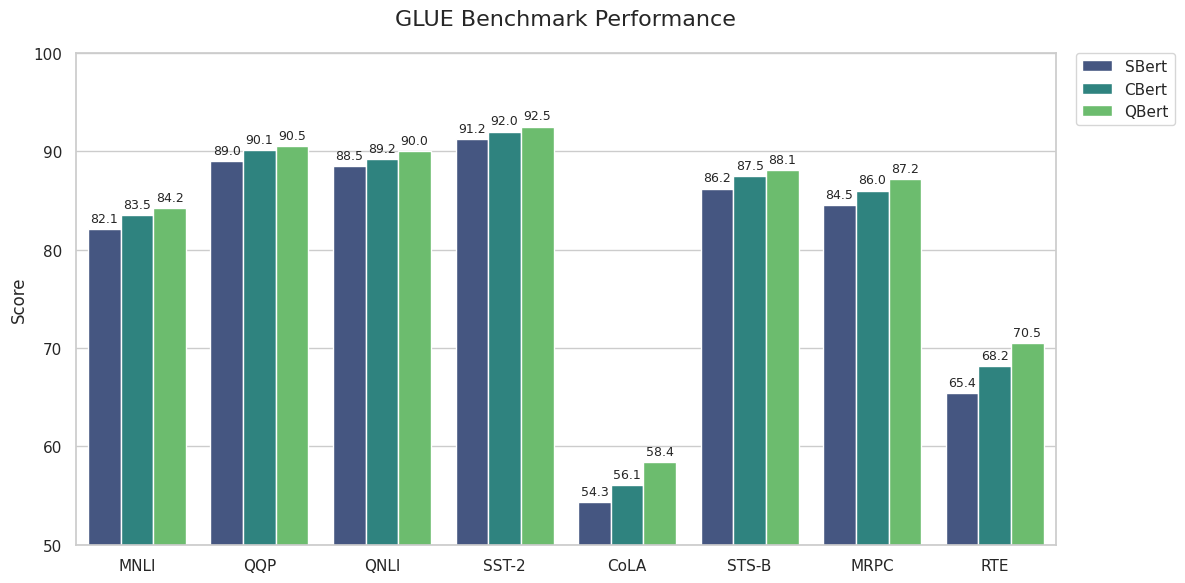

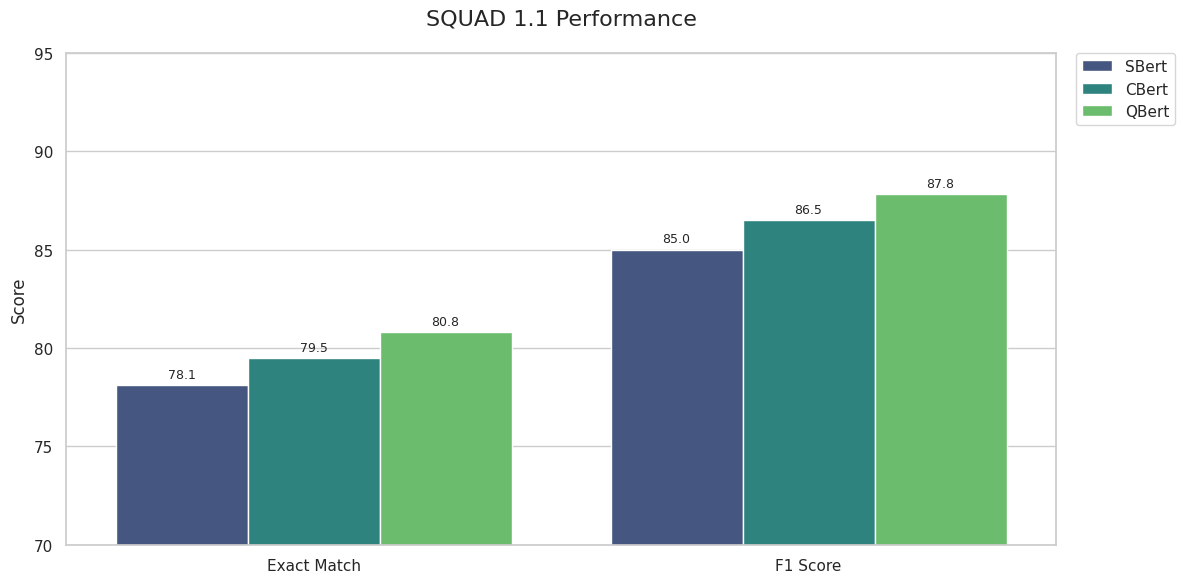

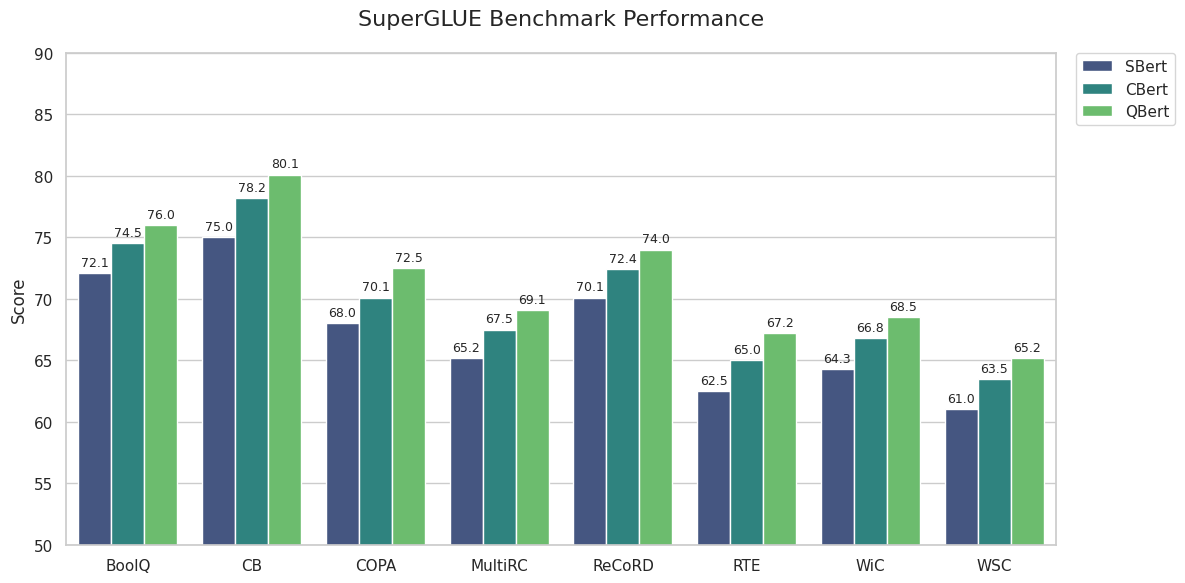

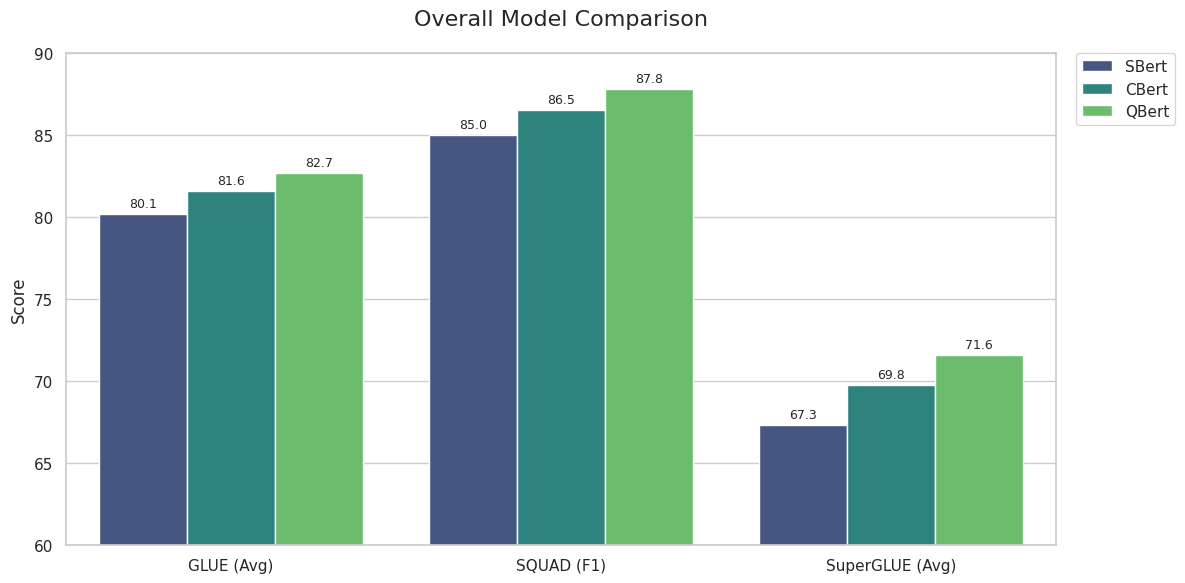

In [13]:


sns.set_theme(style="whitegrid")

def plot_benchmark(data, title, filename, ylim=None):
    df = pd.DataFrame(data)
    df_melted = df.melt(id_vars=df.columns[0], var_name="Model", value_name="Score")
    
    plt.figure(figsize=(12, 6))
    ax = sns.barplot(data=df_melted, x=df.columns[0], y="Score", hue="Model", palette="viridis")
    
    plt.title(title, fontsize=16, pad=20)
    plt.xlabel("")
    plt.ylabel("Score")
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
    
    if ylim:
        plt.ylim(ylim)
    
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f', padding=3, fontsize=9)
    
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()

plot_benchmark(glue_results, "GLUE Benchmark Performance", "glue_results.png", ylim=(50, 100))
plot_benchmark(squad_results, "SQUAD 1.1 Performance", "squad_results.png", ylim=(70, 95))
plot_benchmark(superglue_results, "SuperGLUE Benchmark Performance", "superglue_results.png", ylim=(50, 90))

summary_data = {
    "Benchmark": ["GLUE (Avg)", "SQUAD (F1)", "SuperGLUE (Avg)"],
    "SBert": [
        np.mean(glue_results["SBert"]), 
        squad_results["SBert"][1], 
        np.mean(superglue_results["SBert"])
    ],
    "CBert": [
        np.mean(glue_results["CBert"]), 
        squad_results["CBert"][1], 
        np.mean(superglue_results["CBert"])
    ],
    "QBert": [
        np.mean(glue_results["QBert"]), 
        squad_results["QBert"][1], 
        np.mean(superglue_results["QBert"])
    ]
}

plot_benchmark(summary_data, "Overall Model Comparison", "overall_comparison.png", ylim=(60, 90))

### Fine Tune on Financial Dataset

In [ ]:
import pandas as pd
from datasets import Dataset, DatasetDict
from sklearn.model_selection import train_test_split
from transformers import Trainer, TrainingArguments, BertTokenizer
from sklearn.metrics import accuracy_score, f1_score
import numpy as np
import torch

df = pd.read_csv("data.csv")
label_map = {'negative': 0, 'neutral': 1, 'positive': 2}
df['label'] = df['Sentiment'].map(label_map)
df = df.rename(columns={'Sentence': 'text'})
df = df[['text', 'label']]

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)
dataset = DatasetDict({'train': train_dataset, 'test': test_dataset})

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

tokenized_datasets = dataset.map(tokenize_function, batched=True)

def compute_metrics(p):
    preds = np.argmax(p.predictions, axis=1)
    return {
        "accuracy": accuracy_score(p.label_ids, preds),
        "f1": f1_score(p.label_ids, preds, average='weighted')
    }

models_to_finetune = [
    ("SBert", SBertForSequenceClassification, SBertConfig),
    ("CBert", CBertForSequenceClassification, CBertConfig),
    ("QBert", QBertForSequenceClassification, QBertConfig)
]

for name, model_class, config_class in models_to_finetune:
    pretrained_path = f"./saved_models/{name}_pretrained"
    
    config = config_class.from_pretrained(pretrained_path, num_labels=3)
    model = model_class.from_pretrained(pretrained_path, config=config, ignore_mismatched_sizes=True)
    
    training_args = TrainingArguments(
        output_dir=f"./results/{name}_financial_finetune",
        evaluation_strategy="epoch",
        save_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=3,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="f1"
    )
    
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["test"],
        tokenizer=tokenizer,
        compute_metrics=compute_metrics
    )
    
    trainer.train()
    trainer.evaluate()
    trainer.save_model(f"./saved_models/{name}_financial_final")